# Wunder Predictorium

> **Autores:** Eder Tarifa Fernández y Mario García Berenguer

# Trabajo realizado

## 1 · Introducción

Hay que predecir dos indicadores de movimiento futuro del precio, **`t0`** y **`t1`**, a partir
de la historia reciente del mercado: secuencias de estados del *Limit Order Book* (LOB) + trades.

- Los datos vienen en un único parquet con **secuencias independientes** (`seq_ix`), cada una de
  **1000 pasos** (`step_in_seq` 0–999). Los **99 primeros pasos son *warm-up*** (no se evalúan).
- Cada fila tiene **32 features anónimas**: precios bid (`p0..p5`) y ask (`p6..p11`), sus volúmenes
  (`v0..v11`) y precios/volúmenes de trades (`dp0..dp3`, `dv0..dv3`), más las targets `t0`, `t1`.
- La columna `need_prediction` marca qué filas se puntúan.
- **Métrica**: *weighted Pearson* por target (peso `|y_true|`, así que mandan los pasos con target
  grande), promediada entre `t0` y `t1`, con las predicciones recortadas a `[-6, 6]`. El código de
  entrenamiento usa exactamente esta misma fórmula para que loss y scorer coincidan.

## 2 · Estructura del proyecto

El notebook `main.ipynb` es el **entregable** y es solo una capa fina de orquestación: **no se edita
a mano**, se regenera con `scripts/make_notebook.py`. Todo el trabajo real vive en `src/`:

```
src/
├── data/                # IO de parquet, splits por seq_ix, scaling, ventaneo de secuencias, features tabulares
├── feature_engineering/ # microestructura (spread, imbalance...) + dinámica (momentum)
├── losses/              # weighted Pearson / MSE / composite (alineadas con la métrica)
├── metrics/             # métricas en numpy para reporting
├── models/
│   ├── base.py          # ABCs ClassicalModel / SequenceModel
│   ├── __init__.py      # MODEL_REGISTRY + decorador @register_model
│   ├── classical/       # linear, ridge, random_forest, lightgbm
│   └── sequence/        # gru, lstm, transformer, deeplob, tcn, mamba2, tlob
├── training/            # Trainer (DL) + train_classical_model
├── evaluation/          # Evaluator + plots + escritura de reports
├── submission/          # empaquetado de solution.zip + wrappers de inferencia streaming + ensemble
├── pipeline/            # CLI + orquestador de runs + carga de configs YAML
└── profiling/           # utilidades de análisis exploratorio
```

Añadir un modelo son ~3 líneas: subclase de `ClassicalModel`/`SequenceModel`, decorador
`@register_model("nombre", kind=...)` y un YAML en `configs/models/`. El CLI y el notebook
despachan por el registry.

## 3 · Modelos implementados

**Clásicos** (uno por target, con `sample_weight = |y_true|`): `linear`, `ridge`, `random_forest`,
`lightgbm`. LightGBM es el más fuerte del grupo y acaba siendo clave en el ensemble.

**De secuencia** (consumen `(B, T, F)` → `(B, T, K)`, con heads por target para que `t0` y `t1` no
compitan): `gru`, `lstm`, `transformer` (causal), `deeplob`, **`tcn`** (convoluciones causales
dilatadas; el mejor individual, ~0.274), **`mamba2`** (SSM selectivo *self-contained* en PyTorch
puro, sin kernels CUDA; el *scan* corre en fp32 incluso bajo AMP para no desbordar a NaN) y
**`tlob`** (transformer de doble atención features↔tiempo, con *gradient checkpointing* para caber
en 8 GB de VRAM).

**Ensemble**: promedio ponderado de varios modelos. Los pesos se afinan en validación maximizando
el weighted-Pearson y todo se empaqueta en **un único `solution.zip`** (`EnsemblePredictionModel`).

## 4 · Flujo de ejecución

1. **Carga y split**: se leen train/valid; los splits van **siempre por `seq_ix`** (nunca partir
   filas dentro de una secuencia → evita *leakage*).
2. **Escalado**: `FeatureScaler` (standard) ajustado en train.
3. **Datasets**:
   - DL → `SequenceDataset` (una secuencia = una muestra). En entrenamiento aplica *data
     augmentation*: **crops temporales aleatorios** + jitter de features.
   - Clásicos → tabla con features ingenieradas + rolling.
4. **Entrenamiento**: `Trainer` (AdamW con *weight decay* desacoplado, cosine + warmup, AMP fp16,
   EMA de pesos, early stopping sobre weighted-Pearson) o `train_classical_model`.
5. **Evaluación**: `Evaluator` calcula weighted-Pearson por target (idéntico al scorer) y vuelca
   report a `experiments/<modelo>/<run_id>/`.
6. **Submission**: `packager` genera `solution.zip` con un `PredictionModel` que predice
   **fila a fila** (resetea el estado al cambiar de `seq_ix`, devuelve `None` en warm-up, recorta a
   `[-6, 6]`), aplicando el mismo scaler/features que en entrenamiento.

En el notebook esto es: setup → EDA → feature engineering → 3 rondas de modelos → comparación →
**ensemble (sección 8.bis)** → empaquetado. Un flag `QUICK_MODE` permite un run rápido de prueba.

## 5 · Análisis exploratorio (EDA)

Lo importante que salió del EDA:

- **Anatomía de una secuencia**: se grafican mid-price, spread y targets a lo largo de los 1000
  pasos, marcando la zona de warm-up. Confirma que cada secuencia es un episodio de mercado coherente.
- **Targets**: distribuciones con colas largas; como la métrica pondera por `|y_true|`, casi todo el
  *score* se juega en los pasos de target grande. `t0` y `t1` están poco correlacionadas entre sí.
- **`need_prediction`**: solo una parte de las filas se puntúa (el resto es contexto).
- **Correlación lineal feature ↔ target** (solo sobre filas evaluadas, como la métrica): es **muy
  baja**. Esa es la conclusión que marcó todo el proyecto — es un problema de **señal débil (SNR
  bajo)**, así que el riesgo principal no es la capacidad del modelo sino el **sobreajuste**.

## 6 · Selección de características

Partiendo de las 32 columnas crudas del LOB:

- **Features de microestructura** (instantáneas, por fila): `spread`, `mid_price`, imbalance de
  volumen bid/ask y *depth imbalance* por nivel — combinaciones no lineales (ratios) que tienen
  sentido en HFT.
- **Features de dinámica**: momentum de precio y de volumen, diferencia de momentum bid–ask
  (calculadas **por secuencia**, sin cruzar fronteras de `seq_ix`).
- **Rolling stats**: media/desviación de mid-price y volumen en varias ventanas.

Hallazgo clave: estas features ingenieradas **ayudan a los modelos clásicos** (LightGBM las
aprovecha), pero **no aportan nada a los modelos de secuencia** — un TCN/Mamba ya extrae esa misma
información del raw por sí solo (lo verificamos midiéndolo). Por eso los DL entrenan sobre las **32
features crudas + augmentation**, y reservamos el *feature engineering* para los clásicos.

## 7 · Resultados y conclusiones

- Hay un **techo por target**: `t0 ≈ 0.38`, `t1 ≈ 0.13`. `t1` es el cuello de botella (señal muy
  baja) y arrastra la media. Dos arquitecturas muy distintas (TCN y Mamba-2) llegan al **mismo**
  techo → el límite está en la **predictibilidad de los datos**, no en el modelo.
- Mejores modelos individuales: **TCN ≈ 0.274**, **Mamba-2 ≈ 0.262**.
- La ganancia final vino de **ensamblar modelos decorrelacionados**: promediar TCN + Mamba-2 +
  LightGBM (pesos afinados en validación). LightGBM, al ser de árboles, decorrelaciona mucho más que
  dos redes entre sí, y ahí está el grueso de la mejora.
- **Resultado final: weighted-Pearson ≈ 0.288.**

Lecciones: en señal débil, lo que más rinde es **regularizar y ensamblar**, no agrandar el modelo;
y medir cada idea (augmentation, arquitecturas alternativas, features) antes de darla por buena —
varias hipótesis razonables (dual-trunk, features ingenieradas en DL, más regularización) no
mejoraron y se descartaron con datos.


# Ejecución

## 1 · Setup

Cargamos dependencias, fijamos semillas y un *toggle* `QUICK_MODE` que controla si entrenamos
en modo rápido (subset + pocos epochs, ~10–20 min) o completo (varias horas).

In [38]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import gc
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
try:
    import psutil
    _PROC = psutil.Process()
    def mem_gb() -> float:
        return _PROC.memory_info().rss / 1024**3
except ImportError:
    def mem_gb() -> float:
        return float("nan")

# Silenciar el ruido de mamba-ssm (FutureWarnings de torch.cuda.amp).
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="torch.nn.modules.transformer")

# Asegurar que src/ está en el path cuando el notebook se ejecuta fuera de pytest.
ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

sns.set_theme(context="notebook", style="whitegrid")
np.random.seed(0)
torch.manual_seed(0)

print(f"PyTorch:   {torch.__version__}")
print(f"CUDA:      {torch.cuda.is_available()}", end="")
if torch.cuda.is_available():
    print(f"  ({torch.cuda.get_device_name(0)})")
else:
    print()
print(f"NumPy:     {np.__version__}")
print(f"Pandas:    {pd.__version__}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch:   2.5.1+cu121
CUDA:      True  (NVIDIA GeForce RTX 3060 Ti)
NumPy:     2.4.6
Pandas:    3.0.3


In [39]:
# ⚙️  Toggle global. Cambia a True para iteración rápida.
QUICK_MODE = False

# Subconjunto de secuencias usadas en modo rápido. Pon None para usar todas.
QUICK_N_TRAIN_SEQS = 800
QUICK_N_VAL_SEQS = 250

# Epochs por modelo DL en modo rápido. En modo completo se usan 20 epochs.
QUICK_EPOCHS = 4

# RandomForest escala mal (no usa sample_weight para early-stop). En LOB/HFT
# rara vez gana a LightGBM; ponlo a True si te crashea la RAM o tienes prisa.
SKIP_RF = False

# Mamba-2 con d_model=256 en GPU consumer (RTX 30-series Laptop) es ~30x más
# lento que el resto de DL en full-mode (kernels CUDA nativos saturan el SM).
# Activa este flag si solo quieres validar la arquitectura del resto.
SKIP_MAMBA = False

# TLOB (Garcia et al. 2024) — SOTA específico de LOB. Es el modelo nuevo
# que añadimos a esta iteración. Activa para saltarlo si solo quieres
# validar el resto.
SKIP_TLOB = False

# Salta toda la sección de modelos clásicos (linear/ridge/RF/lightgbm) y va
# directo a los DL. Útil cuando la construcción tabular en CPU no cabe en RAM.
SKIP_CLASSICAL = False

# Rolling features (mid_rmean_{5,20}, mid_rstd_{5,20}, vol_rmean_{5,20}) son
# costosas en memoria (groupby.transform). Las features 'spread', 'imbalance',
# 'momentum'... ya capturan la dinámica básica. Déjalo a False si tu RAM va justa.
WITH_ROLLING = False

# Procesar las features tabulares por chunks de N secuencias para acotar
# el peak de RAM. 200 es un buen compromiso (≈200·1000=200K filas por chunk).
TABULAR_CHUNK_SEQS = 200

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"QUICK_MODE={QUICK_MODE}  DEVICE={DEVICE}  SKIP_CLASSICAL={SKIP_CLASSICAL}  SKIP_RF={SKIP_RF}  SKIP_MAMBA={SKIP_MAMBA}  SKIP_TLOB={SKIP_TLOB}  WITH_ROLLING={WITH_ROLLING}")
print(f"RAM inicial: {mem_gb():.2f} GB")

QUICK_MODE=False  DEVICE=cuda  SKIP_CLASSICAL=False  SKIP_RF=False  SKIP_MAMBA=False  SKIP_TLOB=False  WITH_ROLLING=False
RAM inicial: 7.20 GB


In [40]:
# API del pipeline.
from data import (
    load_train_valid, split_by_seq_ix, FeatureScaler,
    FEATURE_COLS, TARGET_COLS, SEQ_LEN, WARMUP_STEPS, N_FEATURES, N_TARGETS,
    sequences_from_dataframe, SequenceDataset,
    build_tabular_features, make_tabular_dataset,
)
from data.constants import (
    BID_PRICES, ASK_PRICES, BID_VOLUMES, ASK_VOLUMES,
    TRADE_PRICES, TRADE_VOLUMES,
)
from feature_engineering import add_engineered_features, ENGINEERED_FEATURES
from metrics import (
    summary, weighted_pearson_per_target, per_sequence_weighted_pearson,
)
from losses import build_loss
from models import get_model_class, list_models, MODEL_REGISTRY
from training import TrainerConfig, train_classical_model, train_sequence_model
from training.classical_trainer import ClassicalTrainerConfig
from evaluation import Evaluator, write_report, make_run_id

print("modelos registrados:")
for kind in ("classical", "sequence"):
    print(f"  [{kind}] {', '.join(list_models(kind))}")

modelos registrados:
  [classical] lightgbm, linear, random_forest, ridge
  [sequence] deeplob, gru, lstm, mamba2, tcn, tlob, transformer


## 2 · Análisis exploratorio de los datos (EDA)

### Origen de los datos

El reto provee dos parquet ya pre-procesados en `competition_package/datasets/`:

- `train.parquet` — 10 721 secuencias.
- `valid.parquet` — 1 444 secuencias.

Cada secuencia tiene **1000 pasos** independientes; los primeros 99 son *warm-up* (no se evalúan).
Las columnas son 32 features anonimizadas del LOB + trades, más las dos targets (`t0`, `t1`).

In [41]:
# Carga inteligente: si QUICK_MODE, leemos del parquet SOLO las secuencias
# que vamos a usar (filter-pushdown de pyarrow). Saltamos ~92% de la RAM
# vs cargar las 10 721 secuencias completas y luego subsettar.
from data import load_subset

if QUICK_MODE:
    print(f"Cargando subset directamente del parquet ({QUICK_N_TRAIN_SEQS} train + {QUICK_N_VAL_SEQS} val seqs)...")
    train_df = load_subset(
        "competition_package/datasets/train.parquet",
        n_seqs=QUICK_N_TRAIN_SEQS, seed=SEED,
    )
    valid_df = load_subset(
        "competition_package/datasets/valid.parquet",
        n_seqs=QUICK_N_VAL_SEQS, seed=SEED,
    )
else:
    print("Cargando los parquets completos...")
    train_df, valid_df = load_train_valid()

print(f"train: {len(train_df):,} filas · {train_df['seq_ix'].nunique():,} secuencias")
print(f"valid: {len(valid_df):,} filas · {valid_df['seq_ix'].nunique():,} secuencias")
print(f"RAM tras carga: {mem_gb():.2f} GB")
train_df.head()

Cargando los parquets completos...
train: 10,721,000 filas · 10,721 secuencias
valid: 1,444,000 filas · 1,444 secuencias
RAM tras carga: 10.21 GB


,seq_ix,step_in_seq,need_prediction,p0,p1,p2,p3,p4,p5,p6,...,dp0,dp1,dp2,dp3,dv0,dv1,dv2,dv3,t0,t1
0,0,0,False,1.077446,-0.710366,0.373591,0.835558,0.050204,-0.139710,1.367384,...,-0.031078,-0.053527,-0.475214,-0.410787,0.805692,0.516635,-0.368215,-0.503497,-0.564226,1.864018
1,0,1,False,1.100140,-0.562796,0.483658,0.875354,0.138444,-0.010037,1.354714,...,0.950145,-0.083598,-0.604252,-0.703991,-1.925171,1.252957,-1.563974,-1.929990,-0.239079,2.168844
2,0,2,False,1.100140,-0.562796,0.483658,0.875354,0.138444,-0.010037,1.870266,...,-0.168259,1.632066,-0.178565,0.121240,1.377339,1.803970,-0.402838,1.042579,2.237778,2.459723
3,0,3,False,0.955471,-1.486537,0.230353,0.676854,-0.262686,-0.366873,2.011996,...,-0.426942,-0.743530,0.680013,1.394857,0.785266,1.424660,1.258192,0.914074,1.998699,2.272444
4,0,4,False,1.025123,-0.832006,0.317650,0.759677,-0.062770,-0.230353,2.174650,...,0.195700,0.293986,0.494971,0.267884,-1.315502,1.775372,1.302424,1.355667,1.998699,2.324245


In [42]:
# Tamaño en memoria y dtypes — confirmamos que load_dataset hace el downcast a float32.
train_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 10721000 entries, 0 to 10720999
Data columns (total 37 columns):
 #   Column           Dtype  
---  ------           -----  
 0   seq_ix           int64  
 1   step_in_seq      int64  
 2   need_prediction  bool   
 3   p0               float32
 4   p1               float32
 5   p2               float32
 6   p3               float32
 7   p4               float32
 8   p5               float32
 9   p6               float32
 10  p7               float32
 11  p8               float32
 12  p9               float32
 13  p10              float32
 14  p11              float32
 15  v0               float32
 16  v1               float32
 17  v2               float32
 18  v3               float32
 19  v4               float32
 20  v5               float32
 21  v6               float32
 22  v7               float32
 23  v8               float32
 24  v9               float32
 25  v10              float32
 26  v11              float32
 27  dp0              floa

### Distribución de las targets

Las dos targets son indicadores anonimizados de movimientos futuros. La métrica pondera
por `|y_true|`, así que la mayor parte del *score* viene de los pasos con target grande.

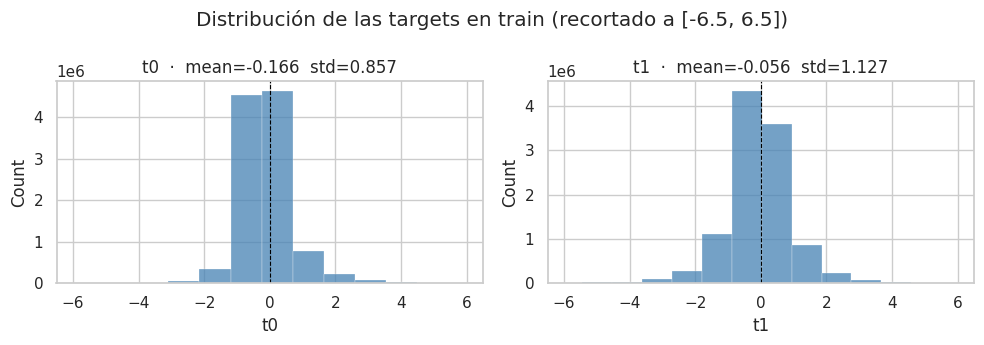

% de filas evaluadas (need_prediction=True): 90.1%
correlación entre t0 y t1 (Pearson): +0.506


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, tgt in zip(axes, TARGET_COLS):
    sns.histplot(train_df[tgt], bins=120, kde=False, ax=ax, color="steelblue")
    ax.set_xlim(-6.5, 6.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{tgt}  ·  mean={train_df[tgt].mean():+.3f}  std={train_df[tgt].std():.3f}")
    ax.set_xlabel(tgt)
fig.suptitle("Distribución de las targets en train (recortado a [-6.5, 6.5])")
fig.tight_layout()
plt.show()

# Cuánta proporción de pasos puntúa.
pct_scored = train_df["need_prediction"].mean() * 100
print(f"% de filas evaluadas (need_prediction=True): {pct_scored:.1f}%")
print(f"correlación entre t0 y t1 (Pearson): {train_df[['t0','t1']].corr().iloc[0,1]:+.3f}")

### Ejemplo: una secuencia completa

Visualizar una sola secuencia ayuda a entender el régimen temporal de los datos.
El mid-price es `(p0 + p6) / 2` (mejor bid + mejor ask) y se construye on-the-fly aquí.

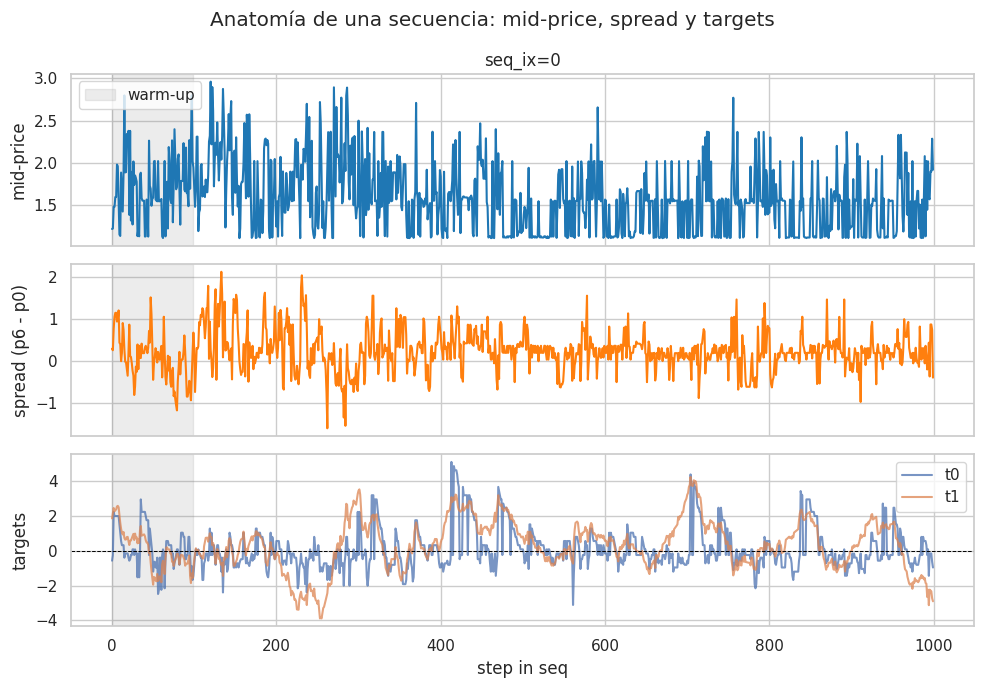

In [44]:
sample_seq_id = int(train_df["seq_ix"].iloc[0])
seq = train_df[train_df["seq_ix"] == sample_seq_id]
mid = (seq["p0"] + seq["p6"]) / 2
spread = seq["p6"] - seq["p0"]

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(seq["step_in_seq"], mid, color="tab:blue")
axes[0].axvspan(0, WARMUP_STEPS, alpha=0.15, color="gray", label="warm-up")
axes[0].set_ylabel("mid-price")
axes[0].set_title(f"seq_ix={sample_seq_id}")
axes[0].legend(loc="upper left")

axes[1].plot(seq["step_in_seq"], spread, color="tab:orange")
axes[1].axvspan(0, WARMUP_STEPS, alpha=0.15, color="gray")
axes[1].set_ylabel("spread (p6 - p0)")

axes[2].plot(seq["step_in_seq"], seq["t0"], label="t0", alpha=0.75)
axes[2].plot(seq["step_in_seq"], seq["t1"], label="t1", alpha=0.75)
axes[2].axvspan(0, WARMUP_STEPS, alpha=0.15, color="gray")
axes[2].axhline(0, color="black", linewidth=0.7, linestyle="--")
axes[2].set_ylabel("targets")
axes[2].set_xlabel("step in seq")
axes[2].legend(loc="upper right")
fig.suptitle("Anatomía de una secuencia: mid-price, spread y targets")
fig.tight_layout()
plt.show()

### Estadísticos de los features

Resumimos en un solo grid las primeras filas + un boxplot por grupo. Los features están
anonimizados pero conservan la estructura típica de LOB (precios escalonados, volúmenes
positivos con cola larga).

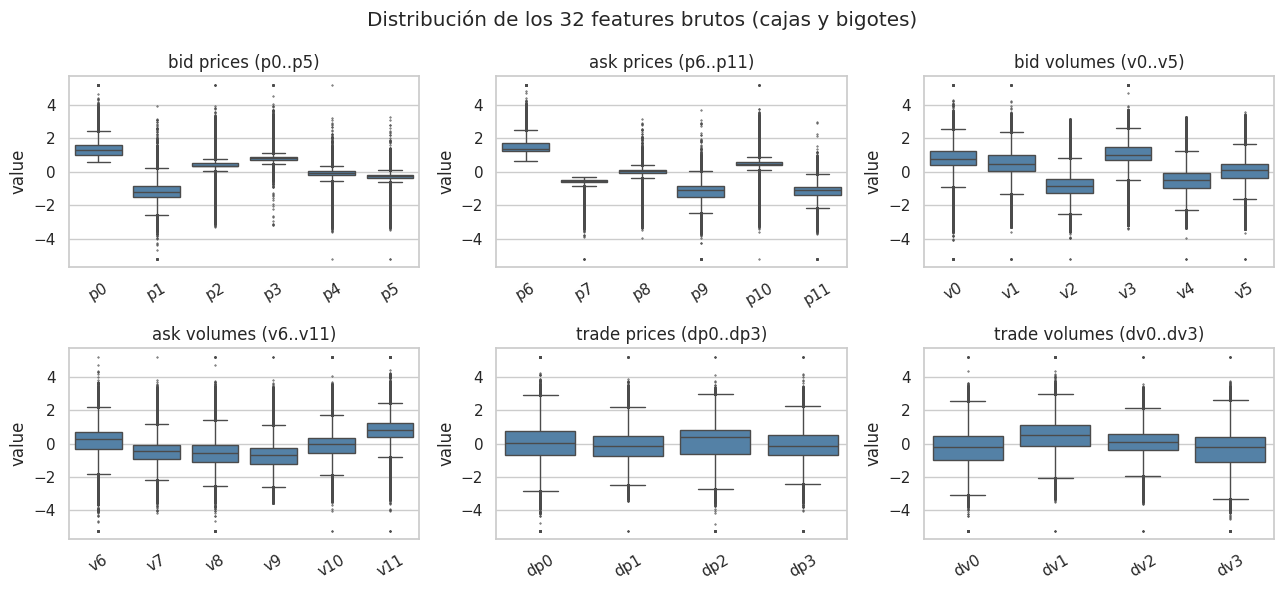

In [45]:
groups = {
    "bid prices (p0..p5)": BID_PRICES,
    "ask prices (p6..p11)": ASK_PRICES,
    "bid volumes (v0..v5)": BID_VOLUMES,
    "ask volumes (v6..v11)": ASK_VOLUMES,
    "trade prices (dp0..dp3)": TRADE_PRICES,
    "trade volumes (dv0..dv3)": TRADE_VOLUMES,
}

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (title, cols) in zip(axes.flat, groups.items()):
    data = train_df[cols].melt(value_name="value", var_name="feature")
    sns.boxplot(data=data, x="feature", y="value", ax=ax, fliersize=0.5, color="steelblue")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel(None)
fig.suptitle("Distribución de los 32 features brutos (cajas y bigotes)")
fig.tight_layout()
plt.show()

### Correlación entre features y targets

Mapa de calor: cada feature contra `t0` y `t1`. Esperamos correlaciones bajas (SNR
microestructural típico) pero algunos features dominan: spread, desequilibrio de
volumen, momentum del mid…

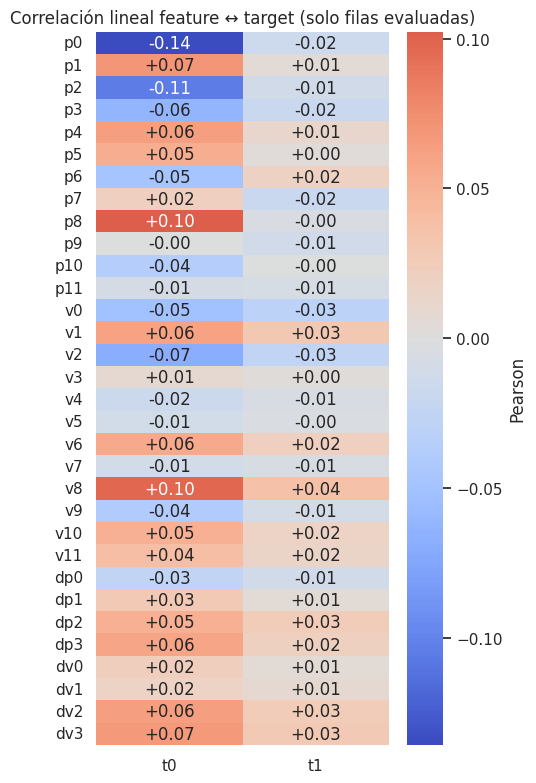

In [46]:
# Calcular correlación solo sobre filas evaluadas (need_prediction=True) — coincide con la métrica.
scored = train_df[train_df["need_prediction"]]
corr_block = scored[FEATURE_COLS + TARGET_COLS].corr().loc[FEATURE_COLS, TARGET_COLS]
plt.figure(figsize=(5, 8))
sns.heatmap(corr_block, cmap="coolwarm", center=0, annot=True, fmt="+.2f",
            cbar_kws={"label": "Pearson"})
plt.title("Correlación lineal feature ↔ target (solo filas evaluadas)")
plt.tight_layout()
plt.show()

## 3 · Feature engineering

El paquete `feature_engineering` añade 12 features derivadas:

* **Microestructura**: `spread`, `mid_price`, `bid_ask_volume_imbalance`, 6 niveles de
  `depth_imbalance_level_k`.
* **Dinámica**: `price_momentum`, `volume_momentum`, `bid_ask_momentum_diff`.

El pipeline (`data.tabular.build_tabular_features`) adicionalmente añade *rolling stats*
multi-ventana (5 y 20 pasos) sobre el mid-price y el volumen total. Todas las
operaciones respetan los límites de secuencia vía `groupby('seq_ix')`.

In [47]:
# Mostrar las features ingenieradas en una muestra pequeña.
sample_ids = train_df["seq_ix"].unique()[:30]
sample = train_df[train_df["seq_ix"].isin(sample_ids)].copy()
sample_eng = add_engineered_features(sample)

new_cols = [c for c in sample_eng.columns if c not in sample.columns]
print(f"features añadidas: {len(new_cols)}")
sample_eng[new_cols].describe().T[["mean", "std", "min", "50%", "max"]]

features añadidas: 12


,mean,std,min,50%,max
spread,0.119798,0.445579,-2.132681,0.151706,2.218807
mid_price,1.507250,0.438900,0.899835,1.461110,3.409179
bid_ask_volume_imbalance,0.054388,0.789140,-1.000000,0.159941,1.000000
depth_imbalance_level_0,0.157561,0.683637,-1.000000,0.215622,1.000000
depth_imbalance_level_1,0.134868,0.819661,-1.000000,0.238078,1.000000
depth_imbalance_level_2,0.119221,0.612334,-1.000000,0.092843,1.000000
depth_imbalance_level_3,0.256886,0.865725,-1.000000,0.869303,1.000000
depth_imbalance_level_4,0.070360,0.738459,-1.000000,0.009373,1.000000
depth_imbalance_level_5,-0.291988,0.684440,-1.000000,-0.436294,1.000000
price_momentum,0.000025,0.348952,-1.847658,0.000000,1.894773


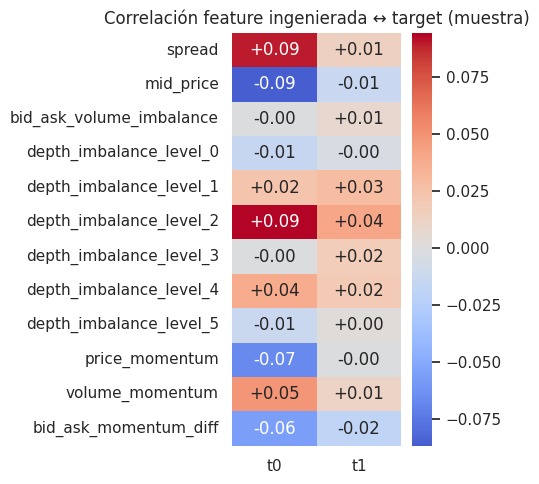

In [48]:
# Correlación de las features ingenieradas con los targets (mejor proxy de utilidad).
scored_sample = sample_eng[sample_eng["need_prediction"]]
corr_eng = scored_sample[new_cols + TARGET_COLS].corr().loc[new_cols, TARGET_COLS]
plt.figure(figsize=(5, 5))
sns.heatmap(corr_eng, cmap="coolwarm", center=0, annot=True, fmt="+.2f")
plt.title("Correlación feature ingenierada ↔ target (muestra)")
plt.tight_layout()
plt.show()

## 4 · Estrategia de modelado

Probaremos 10 modelos en tres rondas. Las claves son:

* **Splits por `seq_ix`** — usamos el `valid.parquet` oficial; jamás partimos filas dentro de una secuencia.
* **Loss alineado con la métrica** — `Weighted Pearson Loss` para los modelos DL (con `clamp(-6, 6)` interno) y `sample_weight = |y_true|` para los clásicos.
* **Evaluación** — `weighted_pearson` por target + media (idéntico al scorer oficial).
* **Reproducibilidad** — semilla 0 en todos los `np.random` / `torch.manual_seed` y, donde aplique, en los estimadores sklearn.

| # | Familia | Modelo | Notas |
|---|---------|--------|-------|
| 1 | Clásico | `linear` | Regresión lineal con `sample_weight=|y|`. |
| 2 | Clásico | `ridge` | L2-regularizado. |
| 3 | Clásico | `random_forest` | Sin escalado. |
| 4 | Clásico | `lightgbm` | Early-stopping sobre weighted Pearson. |
| 5 | DL | `gru` | GRU 2-layer, streamable. |
| 6 | DL | `lstm` | LSTM 2-layer, streamable. |
| 7 | DL | `transformer` | Pre-LN encoder + causal mask. |
| 8 | DL/SOTA | `deeplob` | Zhang 2019 (CNN+LSTM), adaptado a regresión. |
| 9 | DL/SOTA | `tcn` | Temporal Convolutional Network (Bai 2018), dilated causal convs. |
| 10 | DL/SOTA | `mamba2` | Selective SSM (Mamba-2 SSD, PyTorch puro, scan fp32, lineal en T). |
| 11 | DL/SOTA | `tlob` | **Dual-axis Transformer** (Garcia 2024). Attention sobre features + attention causal sobre tiempo. Independente del orden de columnas. |

In [49]:
# Ya no hace falta volver a sub-muestrear — load_subset lo hizo en la carga.
# Renombramos simplemente para mantener la semántica de "datos efectivos".
train_use = train_df
val_use   = valid_df
del train_df, valid_df
gc.collect()

print(f"train_use: {train_use['seq_ix'].nunique()} secuencias · {len(train_use):,} filas")
print(f"val_use:   {val_use['seq_ix'].nunique()} secuencias · {len(val_use):,} filas")
print(f"RAM tras subset: {mem_gb():.2f} GB")

# Scaler — se usa para los modelos DL (no para clásicos).
scaler = FeatureScaler(mode="standard").fit(train_use, FEATURE_COLS)

# Resultados acumulados — se rellenan en las siguientes secciones.
results: list[dict] = []

# Persistencia entre celdas: cada iteración añade su fila aquí.
EXPERIMENTS_ROOT = Path("experiments")
EXPERIMENTS_ROOT.mkdir(exist_ok=True)
NOTEBOOK_RESULTS_CSV = EXPERIMENTS_ROOT / "notebook_results.csv"

def _flush_results():
    """Vuelca la tabla `results` a CSV tras cada iteración."""
    if results:
        pd.DataFrame(results).to_csv(NOTEBOOK_RESULTS_CSV, index=False)
;

train_use: 10721 secuencias · 10,721,000 filas
val_use:   1444 secuencias · 1,444,000 filas
RAM tras subset: 10.63 GB


''

## 5 · Iteración 1 — Baselines clásicos

Estos modelos usan los 32 features brutos **+ las 12 ingenieradas + rolling stats (5, 20)**.
Cada modelo se ajusta por target (one-vs-rest) con `sample_weight = |y_true|`. Tras el
entrenamiento, cada run se persiste en `experiments/<model>/<run_id>/` con `model.joblib`,
`config.yaml`, `metrics.json`, `predictions.parquet`, `scatter.png` y `per_seq_corr.png`.

**Optimización de RAM**: construimos las features tabulares **una sola vez** y las
reutilizamos en los 4 modelos (antes se recomputaban en cada `run_classical`, ×4).

In [50]:
# === Construir features tabulares por CHUNKS (acotamos el peak de RAM) ===
# En vez de transformar el DataFrame entero (que copia ~3 GB transitorios),
# procesamos `TABULAR_CHUNK_SEQS` secuencias a la vez y concatenamos los ndarrays
# finales. Cada chunk libera sus copias intermedias en gc.collect().
from metrics.pearson import _weighted_pearson_scalar  # type: ignore
from evaluation.evaluator import EvalResult
from dataclasses import replace as _dc_replace

ROLLING_WINDOWS = (5, 20) if WITH_ROLLING else ()

if SKIP_CLASSICAL:
    print("⊘ Saltando construcción tabular (SKIP_CLASSICAL=True).")
    train_data = val_data = feature_cols = None

def _build_tabular_arrays_chunked(df, *, chunk_seqs, with_engineered, rolling_windows):
    unique_seqs = df["seq_ix"].unique()
    n_chunks = max(1, len(unique_seqs) // chunk_seqs + bool(len(unique_seqs) % chunk_seqs))
    chunks_X, chunks_y, chunks_w, chunks_sid, chunks_step = [], [], [], [], []
    feature_cols_final = None
    for i, sub_ids in enumerate(np.array_split(unique_seqs, n_chunks)):
        chunk_df = df[df["seq_ix"].isin(sub_ids)]
        tab, cols = build_tabular_features(
            chunk_df, with_engineered=with_engineered, rolling_windows=rolling_windows,
        )
        ds = make_tabular_dataset(tab, cols, only_scored_rows=True, drop_warmup=True)
        feature_cols_final = cols
        chunks_X.append(ds.X);    chunks_y.append(ds.y)
        chunks_w.append(ds.weights); chunks_sid.append(ds.seq_ids); chunks_step.append(ds.step_ids)
        del chunk_df, tab, ds
        gc.collect()
        if (i + 1) % 5 == 0 or i + 1 == n_chunks:
            print(f"    chunk {i+1}/{n_chunks}  ·  RAM {mem_gb():.2f} GB")
    return (
        np.concatenate(chunks_X), np.concatenate(chunks_y),
        np.concatenate(chunks_w), np.concatenate(chunks_sid),
        np.concatenate(chunks_step), feature_cols_final,
    )

if not SKIP_CLASSICAL:
    t0 = time.time()
    print("Building train tabular cache (chunked)...")
    X_tr, y_tr, w_tr, sid_tr, step_tr, feature_cols = _build_tabular_arrays_chunked(
        train_use, chunk_seqs=TABULAR_CHUNK_SEQS, with_engineered=True,
        rolling_windows=ROLLING_WINDOWS,
    )
    print("Building val tabular cache (chunked)...")
    X_va, y_va, w_va, sid_va, step_va, _ = _build_tabular_arrays_chunked(
        val_use, chunk_seqs=TABULAR_CHUNK_SEQS, with_engineered=True,
        rolling_windows=ROLLING_WINDOWS,
    )

    # Re-empaquetar en los TabularDataset dataclass para compatibilidad con el resto.
    from data.tabular import TabularDataset
    train_data = TabularDataset(X=X_tr, y=y_tr, weights=w_tr, seq_ids=sid_tr, step_ids=step_tr,
                                feature_names=feature_cols, target_names=list(TARGET_COLS))
    val_data   = TabularDataset(X=X_va, y=y_va, weights=w_va, seq_ids=sid_va, step_ids=step_va,
                                feature_names=feature_cols, target_names=list(TARGET_COLS))
    del X_tr, y_tr, w_tr, sid_tr, step_tr, X_va, y_va, w_va, sid_va, step_va
    gc.collect()

    print(f"\nfeatures:   {len(feature_cols)}  ({'con' if WITH_ROLLING else 'sin'} rolling)")
    print(f"train_data: X{tuple(train_data.X.shape)}  y{tuple(train_data.y.shape)}")
    print(f"val_data:   X{tuple(val_data.X.shape)}   y{tuple(val_data.y.shape)}")
    print(f"RAM tras tabular cache: {mem_gb():.2f} GB  ·  build en {time.time()-t0:.1f}s")

Building train tabular cache (chunked)...
    chunk 5/54  ·  RAM 10.92 GB
    chunk 10/54  ·  RAM 11.05 GB
    chunk 15/54  ·  RAM 11.20 GB
    chunk 20/54  ·  RAM 11.47 GB
    chunk 25/54  ·  RAM 11.74 GB
    chunk 30/54  ·  RAM 12.01 GB
    chunk 35/54  ·  RAM 12.27 GB
    chunk 40/54  ·  RAM 12.54 GB
    chunk 45/54  ·  RAM 12.80 GB
    chunk 50/54  ·  RAM 13.06 GB
    chunk 54/54  ·  RAM 13.27 GB
Building val tabular cache (chunked)...
    chunk 5/8  ·  RAM 13.05 GB
    chunk 8/8  ·  RAM 13.05 GB

features:   44  (sin rolling)
train_data: X(9659621, 44)  y(9659621, 2)
val_data:   X(1301044, 44)   y(1301044, 2)
RAM tras tabular cache: 13.27 GB  ·  build en 21.1s


In [51]:
def run_classical(name: str, params: dict | None = None):
    ModelCls, kind = get_model_class(name)
    assert kind == "classical", f"{name} no es clásico"
    model = ModelCls(params or {})

    t0 = time.time()
    model.fit(
        train_data.X, train_data.y,
        sample_weight=train_data.weights,
        eval_set=(val_data.X, val_data.y),
        feature_names=feature_cols,
        target_names=val_data.target_names,
    )
    fit_seconds = time.time() - t0

    val_pred = model.predict(val_data.X)
    metrics_dict = summary(val_data.y, val_pred)
    per_seq = {
        int(sid): _weighted_pearson_scalar(val_data.y[val_data.seq_ids == sid],
                                            val_pred[val_data.seq_ids == sid])
        for sid in np.unique(val_data.seq_ids)
    }
    val_eval = EvalResult(
        metrics=metrics_dict, predictions=val_pred, targets=val_data.y,
        seq_ids=val_data.seq_ids, step_ids=val_data.step_ids,
        per_sequence_corr=per_seq,
    )
    wp = metrics_dict["weighted_pearson"]
    per = metrics_dict["per_target"]

    # Persistir el run a disco.
    run_id = make_run_id(name)
    run_dir = EXPERIMENTS_ROOT / name / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    model.save(run_dir / "model.joblib")
    write_report(
        run_dir=run_dir,
        config={"model": {"name": name, "params": params or {}},
                "classical": {"rolling_windows": list(ROLLING_WINDOWS)},
                "quick_mode": QUICK_MODE},
        history=None,
        val_eval=val_eval,
        extra_meta={"kind": "classical", "model_name": name,
                    "feature_columns": feature_cols,
                    "fit_seconds": fit_seconds,
                    "wallclock_seconds": fit_seconds},
    )

    row = {
        "model": name, "kind": "classical",
        "val_weighted_pearson": wp,
        "val_t0": per["t0"], "val_t1": per["t1"],
        "fit_seconds": fit_seconds,
        "n_features": len(feature_cols),
        "wallclock_seconds": fit_seconds,
        "run_dir": str(run_dir),
    }
    results.append(row)
    _flush_results()
    print(f"  ✓ {name:<14} corr={wp:+.4f}  (t0={per['t0']:+.4f}  t1={per['t1']:+.4f})  in {fit_seconds:5.1f}s  →  {run_dir}")
    return model, val_eval
;

''

In [52]:
if SKIP_CLASSICAL:
    print("⊘ Sección clásicos saltada (SKIP_CLASSICAL=True). Pasa directamente a la sec. 6 (DL).")
    linear_model = ridge_model = lgb_model = None
    linear_eval = ridge_eval = lgb_eval = None
    if 'rf_model' not in dir(): rf_model = None
    if 'rf_eval' not in dir():  rf_eval = None
else:
    # Linear (un punto de partida — diagnóstico de señal lineal).
    linear_model, linear_eval = run_classical("linear")

  ✓ linear         corr=+0.1750  (t0=+0.2823  t1=+0.0676)  in  13.4s  →  experiments/linear/linear__20260530-234807


In [53]:
if not SKIP_CLASSICAL:
    # Ridge — versión regularizada.
    ridge_model, ridge_eval = run_classical("ridge", {"alpha": 1.0})

  ✓ ridge          corr=+0.1750  (t0=+0.2823  t1=+0.0676)  in  71.7s  →  experiments/ridge/ridge__20260530-234927


In [54]:
# Random Forest — modelo no-lineal.
#
# ⚠️  RF de sklearn no soporta early-stopping con la métrica del reto y escala mal
# con muchas filas + alta profundidad. En LOB/HFT casi nunca gana a LightGBM (ver
# writeups Optiver, JPX, G-Research). Por eso usamos hiperparámetros conservadores
# incluso en modo completo: lo importante es tenerlo en la comparativa, no batirlo.
#
# Tiempo aproximado en CPU 8-core:
#   QUICK_MODE=True   → ~3-5 min  (40 árboles × depth 8 sobre 1.35M filas)
#   QUICK_MODE=False  → ~30-60 min  (100 árboles × depth 10 sobre 9.6M filas)
#
# Si tienes prisa o poca RAM, pon SKIP_RF=True arriba.
if SKIP_CLASSICAL or SKIP_RF:
    if not SKIP_CLASSICAL:
        print("  ⊘  random_forest saltado (SKIP_RF=True)")
else:
    rf_params = (
        {  # QUICK_MODE
            "n_estimators": 40, "max_depth": 8, "min_samples_leaf": 500,
            "max_features": 0.5, "n_jobs": -1, "random_state": SEED,
        }
        if QUICK_MODE else
        {  # full mode — conservador a propósito
            "n_estimators": 100, "max_depth": 10, "min_samples_leaf": 500,
            "max_features": 0.5, "n_jobs": -1, "random_state": SEED,
        }
    )
    rf_model, rf_eval = run_classical("random_forest", rf_params)

  ✓ random_forest  corr=+0.1736  (t0=+0.2880  t1=+0.0592)  in 7534.2s  →  experiments/random_forest/random_forest__20260531-015511


In [55]:
if not SKIP_CLASSICAL:
    # LightGBM — históricamente el rey en Kaggles de microestructura.
    lgb_model, lgb_eval = run_classical(
        "lightgbm",
        {
            "params": {
                "objective": "regression", "metric": "None",
                "learning_rate": 0.05, "num_leaves": 63,
                "min_data_in_leaf": 100, "feature_fraction": 0.8,
                "bagging_fraction": 0.8, "bagging_freq": 5,
                "lambda_l2": 1.0, "verbose": -1,
            },
            "num_boost_round": 400 if QUICK_MODE else 3000,
            "early_stopping_rounds": 50,
            "log_period": 100000,
        },
    )

    # Liberar la cache tabular: los clásicos ya están entrenados y persistidos.
    del train_data, val_data
    gc.collect()
    print(f"RAM tras liberar tabular cache: {mem_gb():.2f} GB")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[155]	train's weighted_pearson: 0.413968	valid's weighted_pearson: 0.32749
Evaluated only: weighted_pearson
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[165]	train's weighted_pearson: 0.378506	valid's weighted_pearson: 0.069448
Evaluated only: weighted_pearson
  ✓ lightgbm       corr=+0.1985  (t0=+0.3275  t1=+0.0694)  in 197.8s  →  experiments/lightgbm/lightgbm__20260531-015838
RAM tras liberar tabular cache: 5.98 GB


## 6 · Iteración 2 — Modelos secuenciales DL básicos

Los DL ven la secuencia completa de 1000 pasos. El loss enmascara el warm-up (pasos < 99).
En modo rápido entrenamos 4 epochs con d_hidden 64 para iterar cómodo; en modo completo,
los hiperparámetros se mueven a los valores de `configs/models/<name>.yaml`.

In [56]:
# Construir datasets una sola vez (reutilizables para todos los modelos secuenciales).
# Escalamos justo ahora (mantenemos los DataFrames escalados solo durante la sección DL).
train_scaled = scaler.transform(train_use)
val_scaled   = scaler.transform(val_use)
# Ya no necesitamos train_use / val_use crudos: el evaluator de DL trabaja sobre los escalados.
del train_use, val_use
gc.collect()

# Augmentation SOLO en train: crops temporales aleatorios + jitter de features.
# Con ~10.7k secuencias fijas, un modelo de alta capacidad memoriza en pocas
# epochs (Mamba-2 daba su mejor val en la epoch ~5). Los crops convierten esas
# 10.7k ventanas fijas en sub-trayectorias prácticamente ilimitadas -> es la
# palanca anti-overfit nº1. El val_ds queda intacto (secuencias completas,
# sin ruido) para que su weighted-Pearson sea comparable al scorer.
AUGMENT = {} if QUICK_MODE else {"crop_len": 512, "jitter_std": 0.05}

train_arr = sequences_from_dataframe(train_scaled)
val_arr   = sequences_from_dataframe(val_scaled)
train_ds  = SequenceDataset(train_arr, seed=SEED, **AUGMENT)
val_ds    = SequenceDataset(val_arr)
# Las arrays están ya copiadas dentro del Dataset; podemos soltar las versiones intermedias.
del train_arr
gc.collect()

print(f"train_ds: {len(train_ds)} secuencias  ·  val_ds: {len(val_ds)} secuencias"
      f"  ·  augment: {AUGMENT or 'off'}")
print(f"RAM tras montar sequence datasets: {mem_gb():.2f} GB")

train_ds: 10721 secuencias  ·  val_ds: 1444 secuencias  ·  augment: {'crop_len': 512, 'jitter_std': 0.05}
RAM tras montar sequence datasets: 9.00 GB


In [57]:
def run_sequence(name: str, params: dict | None = None, *, trainer_overrides: dict | None = None):
    ModelCls, kind = get_model_class(name)
    assert kind == "sequence", f"{name} no es secuencial"
    params = {**(params or {}), "n_features": N_FEATURES, "n_targets": N_TARGETS}
    model = ModelCls(params)

    cfg_dict = dict(
        epochs=QUICK_EPOCHS if QUICK_MODE else 20,
        batch_size=16 if QUICK_MODE else 32,
        learning_rate=1e-3,
        weight_decay=1e-4,
        warmup_epochs=0 if QUICK_MODE else 1,
        grad_clip=1.0,
        eval_every=1,
        device=DEVICE,
        amp=(DEVICE == "cuda"),
        seed=SEED,
        loss_name="weighted_pearson",
        early_stopping_patience=2 if QUICK_MODE else 5,
        num_workers=0,
        pin_memory=(DEVICE == "cuda"),
    )
    cfg_dict.update(trainer_overrides or {})
    trainer_cfg = TrainerConfig(**cfg_dict)

    t0 = time.time()
    info = train_sequence_model(model, train_ds, val_ds, trainer_cfg)
    elapsed = time.time() - t0

    ev = Evaluator()
    val_eval = ev.run_sequence_model(model, val_scaled, device=trainer_cfg.resolve_device())
    wp = val_eval.metrics["weighted_pearson"]
    per = val_eval.metrics["per_target"]

    # Persistir el run a disco (weights + métricas + plots + history).
    run_id = make_run_id(name)
    run_dir = EXPERIMENTS_ROOT / name / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    model.save(run_dir / "model.pt")
    write_report(
        run_dir=run_dir,
        config={"model": {"name": name, "params": params},
                "training": cfg_dict,
                "quick_mode": QUICK_MODE},
        history=info["history"],
        val_eval=val_eval,
        extra_meta={"kind": "sequence", "model_name": name,
                    "best_score_during_train": float(info["best_score"]),
                    "wallclock_seconds": elapsed},
    )

    row = {
        "model": name,
        "kind": "sequence",
        "val_weighted_pearson": wp,
        "val_t0": per["t0"],
        "val_t1": per["t1"],
        "fit_seconds": elapsed,
        "epochs_done": len(info["history"]),
        "best_score_during_train": info["best_score"],
        "wallclock_seconds": elapsed,
        "run_dir": str(run_dir),
    }
    results.append(row)
    _flush_results()
    print(f"  ✓ {name:<14} corr={wp:+.4f}  (t0={per['t0']:+.4f}  t1={per['t1']:+.4f})  epochs={len(info['history'])}  in {elapsed:5.1f}s  →  {run_dir}")
    return model, info, val_eval
;

''

In [58]:
gru_model, gru_info, gru_eval = run_sequence(
    "gru",
    {"hidden_size": 64 if QUICK_MODE else 128, "num_layers": 2, "dropout": 0.1},
)

epoch   1 | loss 0.83890 | val_corr +0.2101 | best +0.2101 | lr 1.00e-03 | 7.1s  *

epoch   2 | loss 0.75938 | val_corr +0.2458 | best +0.2458 | lr 9.93e-04 | 6.3s  *

epoch   3 | loss 0.74430 | val_corr +0.2458 | best +0.2458 | lr 9.73e-04 | 6.2s

epoch   4 | loss 0.73521 | val_corr +0.2533 | best +0.2533 | lr 9.40e-04 | 6.2s  *

epoch   5 | loss 0.72788 | val_corr +0.2572 | best +0.2572 | lr 8.95e-04 | 6.4s  *

...

epoch  10 | loss 0.68534 | val_corr +0.2382 | best +0.2584 | lr 5.41e-04 | 6.2s

epoch  11 | loss 0.66935 | val_corr +0.2440 | best +0.2584 | lr 4.59e-04 | 6.2s

epoch  12 | loss 0.64484 | val_corr +0.2156 | best +0.2584 | lr 3.77e-04 | 6.2s

early stopping at epoch 12 (no improvement in 5 epochs)

  ✓ gru            corr=+0.2584  (t0=+0.3757  t1=+0.1412)  epochs=12  in  76.7s  →  experiments/gru/gru__20260531-020029


In [59]:
lstm_model, lstm_info, lstm_eval = run_sequence(
    "lstm",
    {"hidden_size": 64 if QUICK_MODE else 128, "num_layers": 2, "dropout": 0.1},
)

epoch   1 | loss 0.83858 | val_corr +0.2215 | best +0.2215 | lr 1.00e-03 | 6.7s  *

epoch   2 | loss 0.76213 | val_corr +0.2359 | best +0.2359 | lr 9.93e-04 | 6.4s  *

epoch   3 | loss 0.74714 | val_corr +0.2428 | best +0.2428 | lr 9.73e-04 | 6.4s  *

epoch   4 | loss 0.73607 | val_corr +0.2426 | best +0.2428 | lr 9.40e-04 | 6.4s

epoch   5 | loss 0.73293 | val_corr +0.2572 | best +0.2572 | lr 8.95e-04 | 6.5s  *

...

epoch  10 | loss 0.70815 | val_corr +0.2662 | best +0.2666 | lr 5.41e-04 | 6.6s

epoch  11 | loss 0.70374 | val_corr +0.2631 | best +0.2666 | lr 4.59e-04 | 6.5s

epoch  12 | loss 0.68816 | val_corr +0.2404 | best +0.2666 | lr 3.77e-04 | 6.6s

early stopping at epoch 12 (no improvement in 5 epochs)

  ✓ lstm           corr=+0.2666  (t0=+0.3927  t1=+0.1405)  epochs=12  in  77.9s  →  experiments/lstm/lstm__20260531-020156


In [60]:
transformer_model, tfm_info, tfm_eval = run_sequence(
    "transformer",
    {
        "d_model": 64 if QUICK_MODE else 128,
        "nhead": 4,
        "num_layers": 2 if QUICK_MODE else 3,
        "dim_feedforward": 128 if QUICK_MODE else 256,
        "dropout": 0.1,
        "max_len": 1024,
    },
)

epoch   1 | loss 0.83531 | val_corr +0.1948 | best +0.1948 | lr 1.00e-03 | 9.1s  *

epoch   2 | loss 0.78680 | val_corr +0.1974 | best +0.1974 | lr 9.93e-04 | 8.9s  *

epoch   3 | loss 0.77754 | val_corr +0.2059 | best +0.2059 | lr 9.73e-04 | 8.9s  *

epoch   4 | loss 0.76739 | val_corr +0.2136 | best +0.2136 | lr 9.40e-04 | 8.9s  *

epoch   5 | loss 0.76038 | val_corr +0.2272 | best +0.2272 | lr 8.95e-04 | 8.9s  *

...

epoch   8 | loss 0.75243 | val_corr +0.2268 | best +0.2272 | lr 7.01e-04 | 8.9s

epoch   9 | loss 0.74983 | val_corr +0.2264 | best +0.2272 | lr 6.23e-04 | 8.9s

epoch  10 | loss 0.74902 | val_corr +0.2241 | best +0.2272 | lr 5.41e-04 | 8.9s

early stopping at epoch 10 (no improvement in 5 epochs)

  ✓ transformer    corr=+0.2272  (t0=+0.3416  t1=+0.1128)  epochs=10  in  89.3s  →  experiments/transformer/transformer__20260531-020335


## 7 · Iteración 3 — Modelos específicos / SOTA

**DeepLOB** (Zhang 2019) — CNN multi-escala + bloque inception + LSTM publicado en IEEE TSP.
En el paper original cada ventana de 100 pasos produce **una sola** predicción softmax para
el movimiento de mid-price en `T + k`, así que las convs internas no se preocupan por la
causalidad: toda la ventana es pasado respecto al target.

En este reto el target es **per-step** sobre secuencias de 1000 pasos, así que el port ingenuo
(mismas convs `(4,1)` sin padding + `F.interpolate` para recuperar `T`) introduce *look-ahead*
de ~20 pasos al material de cada predicción. Nuestra adaptación: (i) cabeza softmax → `Linear(2)`
por paso, (ii) todas las convs temporales pasan a **causales** (left-pad solo), (iii) se
elimina el upsample porque la pila causal preserva `T`. Esto se valida con
`tests/models/test_registry.py::test_deeplob_streaming_matches_forward` (paridad batched↔streaming).

**TCN** (Bai, Kolter & Koltun 2018) — *Temporal Convolutional Network*: pila residual de
convs 1-D **causales** con dilatación exponencial (1, 2, 4, 8, 16, …). Con 5 bloques y
kernel 3 cubre un *receptive field* de 125 pasos con ~125 k parámetros — mucho más eficiente
que la pila kernel-4 de DeepLOB y sin el cuello de botella recurrente de los RNN. La
causalidad es por construcción: cada bloque hace `F.pad(..., (k-1)*d, 0)` (left-only),
así que el output en `t` depende solo de inputs `<= t`. Se valida con
`tests/models/test_registry.py::test_tcn_streaming_matches_forward` y `test_tcn_causality`.
Para entender la arquitectura en detalle, ver `docs/tcn.md`.

**Mamba-2** (Dao & Gu 2024) — *Selective State-Space Model* con coste **lineal** en T (sin
matriz de atención O(T²)). Implementación **propia en PyTorch puro** (algoritmo SSD por
*chunks*); no depende de `mamba-ssm`/`causal-conv1d` (que no compilan fácil en WSL2). El
*scan* selectivo corre en **fp32 aun bajo AMP fp16**, así que los `exp()`/`cumsum` del
decaimiento nunca desbordan a NaN → no hay colapso de la métrica. Incluye streaming
recurrente O(1) por paso para el scorer. Ver `src/models/sequence/mamba2.py`.

In [61]:
deeplob_model, deeplob_info, deeplob_eval = run_sequence(
    "deeplob",
    {
        "window_size": 100,
        "lstm_hidden": 32 if QUICK_MODE else 64,
        "c1": 16, "c2": 16, "c3": 32,
        "inception_channels": 16 if QUICK_MODE else 32,
        "dropout": 0.1,
    },
    trainer_overrides={"learning_rate": 1e-4},
)

epoch   1 | loss 1.00035 | val_corr +0.0318 | best +0.0318 | lr 1.00e-04 | 7.1s  *

epoch   2 | loss 0.98069 | val_corr +0.0306 | best +0.0318 | lr 9.93e-05 | 6.8s

epoch   3 | loss 0.96333 | val_corr +0.0383 | best +0.0383 | lr 9.73e-05 | 6.9s  *

epoch   4 | loss 0.96056 | val_corr +0.0465 | best +0.0465 | lr 9.40e-05 | 6.8s  *

epoch   5 | loss 0.95749 | val_corr +0.0459 | best +0.0465 | lr 8.95e-05 | 6.8s

...

epoch  17 | loss 0.93790 | val_corr +0.0755 | best +0.0801 | lr 6.03e-06 | 6.9s

epoch  18 | loss 0.93491 | val_corr +0.0775 | best +0.0801 | lr 2.71e-06 | 6.8s

epoch  19 | loss 0.93475 | val_corr +0.0750 | best +0.0801 | lr 6.82e-07 | 6.8s

early stopping at epoch 19 (no improvement in 5 epochs)

  ✓ deeplob        corr=+0.0801  (t0=+0.1364  t1=+0.0239)  epochs=19  in 133.0s  →  experiments/deeplob/deeplob__20260531-020556


In [62]:
# Config tuneada vía scripts/sweep_tcn.py (variante C_L6_ch96, val=+0.2740).
# En QUICK_MODE bajamos canales y capas para acotar tiempo.
tcn_model, tcn_info, tcn_eval = run_sequence(
    "tcn",
    {
        "channels": 48 if QUICK_MODE else 96,
        "num_layers": 5 if QUICK_MODE else 6,    # RF: quick=125, full=253
        "kernel_size": 3,
        "dropout": 0.1,
    },
)

epoch   1 | loss 0.81592 | val_corr +0.2333 | best +0.2333 | lr 1.00e-03 | 7.0s  *

epoch   2 | loss 0.75718 | val_corr +0.2413 | best +0.2413 | lr 9.93e-04 | 6.6s  *

epoch   3 | loss 0.74214 | val_corr +0.2409 | best +0.2413 | lr 9.73e-04 | 6.5s

epoch   4 | loss 0.73855 | val_corr +0.2459 | best +0.2459 | lr 9.40e-04 | 6.5s  *

epoch   5 | loss 0.73199 | val_corr +0.2612 | best +0.2612 | lr 8.95e-04 | 6.5s  *

...

epoch  15 | loss 0.68357 | val_corr +0.2674 | best +0.2778 | lr 1.61e-04 | 6.5s

epoch  16 | loss 0.68161 | val_corr +0.2660 | best +0.2778 | lr 1.05e-04 | 6.5s

epoch  17 | loss 0.67303 | val_corr +0.2610 | best +0.2778 | lr 6.03e-05 | 6.5s

early stopping at epoch 17 (no improvement in 5 epochs)

  ✓ tcn            corr=+0.2778  (t0=+0.4019  t1=+0.1537)  epochs=17  in 111.7s  →  experiments/tcn/tcn__20260531-020757


In [63]:
# Mamba-2 (SSD, PyTorch puro) — preset CAPACIDAD ALTA + AUGMENTATION:
# Experimentos medidos: subir regularización BAJÓ el pico (0.262->0.248) y las
# ramas por target (dual-trunk) NO ayudaron (t1 colapsa igual con rama propia,
# luego no era interferencia t0/t1 sino que t1 es un target de baja señal que
# sobre-ajusta a ~0 por sí solo). Receta ganadora: capacidad alta + augmentation
# (crops 512, retrasan el colapso) + early-stopping (guarda el pico; el colapso
# nunca llega al checkpoint shippeado).
# · d_model=256 · 8 capas · d_state=128 · headdim=64  (~3.7M params)
# · dropout 0.2 + drop_path 0.1 (reg ligera); weight_decay 0.01 (param groups)
# · LR 2e-4, warmup 4, 100 epochs, paciencia 15; augment crops 512 + jitter
# · ~4.6 GB pico @ batch=24, T=512 en la 3060 Ti  ->  ~1.5 min/epoch
# (Dual-trunk sigue disponible vía split_targets=True pero no aporta; off.)
if SKIP_MAMBA:
    mamba_model, mamba_info, mamba_eval = None, None, None
    print("Saltando Mamba-2 (SKIP_MAMBA=True).")
else:
    mamba_model, mamba_info, mamba_eval = run_sequence(
        "mamba2",
        {
            "d_model": 128 if QUICK_MODE else 256,
            "num_layers": 4 if QUICK_MODE else 8,
            "headdim": 64,
            "d_state": 64 if QUICK_MODE else 128,
            "expand": 2,
            "chunk_size": 128,        # 512 es múltiplo de 128 -> sin padding
            "dropout": 0.2,
            "drop_path": 0.1,
        },
        trainer_overrides={
            "learning_rate": 2e-4,
            "weight_decay": 1e-2,
            "warmup_epochs": 1 if QUICK_MODE else 4,
            "epochs": QUICK_EPOCHS if QUICK_MODE else 100,
            "early_stopping_patience": 4 if QUICK_MODE else 15,
            "ema_decay": 0.999,
            "batch_size": 24,         # ~4.6 GB pico; sube a 32 (6.2 GB) si quieres
        },
    )
    print(f"\nMamba-2 topology: {mamba_model.backend_used} "
          f"({sum(p.numel() for p in mamba_model.parameters())/1e6:.2f} M params)")

epoch   1 | loss 0.85990 | val_corr +0.1263 | best +0.1263 | lr 5.01e-05 | 108.1s  *

epoch   2 | loss 0.77873 | val_corr +0.2010 | best +0.2010 | lr 1.00e-04 | 107.9s  *

epoch   3 | loss 0.75520 | val_corr +0.2245 | best +0.2245 | lr 1.50e-04 | 107.9s  *

epoch   4 | loss 0.74329 | val_corr +0.2364 | best +0.2364 | lr 2.00e-04 | 107.9s  *

epoch   5 | loss 0.73193 | val_corr +0.2445 | best +0.2445 | lr 2.00e-04 | 107.9s  *

...

epoch  20 | loss 0.47662 | val_corr +0.1494 | best +0.2508 | lr 1.87e-04 | 108.0s

epoch  21 | loss 0.45977 | val_corr +0.1440 | best +0.2508 | lr 1.85e-04 | 107.9s

epoch  22 | loss 0.45314 | val_corr +0.1420 | best +0.2508 | lr 1.83e-04 | 107.9s

early stopping at epoch 22 (no improvement in 15 epochs)

  ✓ mamba2         corr=+0.2508  (t0=+0.3757  t1=+0.1259)  epochs=22  in 2374.5s  →  experiments/mamba2/mamba2__20260531-024750

Mamba-2 topology: pytorch_ssd (3.73 M params)


In [64]:
# TLOB (Garcia et al., 2024, arXiv:2403.09989) — el SOTA específico de LOB.
# Doble attention: features (cada timestep atiende a las 32 columnas)
# + tiempo (cada feature atiende causalmente al pasado). Per-target heads.
#
# CONFIG BAJO-VRAM + MÁS REGULARIZADA (la anterior d64/L4 hacía OOM en la
# 3060 Ti: 5.86 GB de pico + fragmentación tras un run largo). Fixes:
#   · grad_checkpoint=True -> recomputa los bloques en backward: 5.86 -> 1.50 GB
#     (mismo modelo, exacto, ~30% más lento). ES la palanca clave.
#   · modelo más pequeño (d48/L3) + dropout 0.35 + drop_path 0.30
#   · los crops de 512 (AUGMENT global) ~bajan a la mitad la activación dominante
#   -> pico ~0.5-0.6 GB. Si aun así OOM en runs largos, lanza con
#      PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
if SKIP_TLOB:
    tlob_model, tlob_info, tlob_eval = None, None, None
    print("Saltando TLOB (SKIP_TLOB=True).")
else:
    tlob_model, tlob_info, tlob_eval = run_sequence(
        "tlob",
        {
            "d_model": 48,
            "num_layers": 2 if QUICK_MODE else 3,
            "n_heads": 4,
            "ffn_mult": 4,
            "dropout": 0.25 if QUICK_MODE else 0.35,
            "drop_path": 0.10 if QUICK_MODE else 0.30,
            "max_len": 1024,
            "grad_checkpoint": not QUICK_MODE,
        },
        trainer_overrides={
            "learning_rate": 3e-4,
            "weight_decay": 5e-4 if QUICK_MODE else 8e-3,
            "warmup_epochs": 1 if QUICK_MODE else 6,
            "epochs": QUICK_EPOCHS if QUICK_MODE else 100,
            "early_stopping_patience": 4 if QUICK_MODE else 15,
            "ema_decay": 0.999,
            "batch_size": 8,
        },
    )

# Liberamos las arrays / datasets de secuencias — ya están persistidas y los
# val_eval que necesita la sección 8 quedaron en memoria como objetos Python pequeños.
del val_arr, train_ds, val_ds, train_scaled
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f"RAM tras liberar sequence datasets: {mem_gb():.2f} GB")

epoch   1 | loss 0.99654 | val_corr +0.0073 | best +0.0073 | lr 5.00e-05 | 206.5s  *

epoch   2 | loss 0.95801 | val_corr +0.0387 | best +0.0387 | lr 1.00e-04 | 206.6s  *

epoch   3 | loss 0.84977 | val_corr +0.0832 | best +0.0832 | lr 1.50e-04 | 206.8s  *

epoch   4 | loss 0.82244 | val_corr +0.0984 | best +0.0984 | lr 2.00e-04 | 208.0s  *

epoch   5 | loss 0.80492 | val_corr +0.1092 | best +0.1092 | lr 2.50e-04 | 206.8s  *

...

epoch  40 | loss 0.76336 | val_corr +0.1643 | best +0.1769 | lr 2.13e-04 | 207.7s

epoch  41 | loss 0.76187 | val_corr +0.1602 | best +0.1769 | lr 2.09e-04 | 207.0s

epoch  42 | loss 0.76136 | val_corr +0.1629 | best +0.1769 | lr 2.04e-04 | 207.0s

early stopping at epoch 42 (no improvement in 15 epochs)

  ✓ tlob           corr=+0.1769  (t0=+0.2871  t1=+0.0668)  epochs=42  in 8715.9s  →  experiments/tlob/tlob__20260531-051712
RAM tras liberar sequence datasets: 4.99 GB


## 8 · Comparativa y mejor modelo individual

Recopilamos los resultados de las tres rondas, ordenamos por `val_weighted_pearson` y
examinamos en detalle los dos mejores (scatter de predicción vs target y distribución
de correlación por secuencia).

In [65]:
results_df = pd.DataFrame(results).sort_values("val_weighted_pearson", ascending=False).reset_index(drop=True)
results_df.style.format({
    "val_weighted_pearson": "{:+.4f}",
    "val_t0": "{:+.4f}",
    "val_t1": "{:+.4f}",
    "fit_seconds": "{:.1f}",
    "wallclock_seconds": "{:.1f}",
}).background_gradient(subset=["val_weighted_pearson"], cmap="RdYlGn")

,model,kind,val_weighted_pearson,val_t0,val_t1,fit_seconds,n_features,wallclock_seconds,run_dir,epochs_done,best_score_during_train
0,tcn,sequence,+0.2778,+0.4019,+0.1537,111.7,nan,111.7,experiments/tcn/tcn__20260531-020757,17.000000,0.277796
1,lstm,sequence,+0.2666,+0.3927,+0.1405,77.9,nan,77.9,experiments/lstm/lstm__20260531-020156,12.000000,0.266591
2,gru,sequence,+0.2584,+0.3757,+0.1412,76.7,nan,76.7,experiments/gru/gru__20260531-020029,12.000000,0.258436
3,mamba2,sequence,+0.2508,+0.3757,+0.1259,2374.5,nan,2374.5,experiments/mamba2/mamba2__20260531-024750,22.000000,0.250801
4,transformer,sequence,+0.2272,+0.3416,+0.1128,89.3,nan,89.3,experiments/transformer/transformer__20260531-020335,10.000000,0.227192
5,lightgbm,classical,+0.1985,+0.3275,+0.0694,197.8,44.000000,197.8,experiments/lightgbm/lightgbm__20260531-015838,nan,nan
6,tlob,sequence,+0.1769,+0.2871,+0.0668,8715.9,nan,8715.9,experiments/tlob/tlob__20260531-051712,42.000000,0.176941
7,ridge,classical,+0.1750,+0.2823,+0.0676,71.7,44.000000,71.7,experiments/ridge/ridge__20260530-234927,nan,nan
8,linear,classical,+0.1750,+0.2823,+0.0676,13.4,44.000000,13.4,experiments/linear/linear__20260530-234807,nan,nan
9,random_forest,classical,+0.1736,+0.2880,+0.0592,7534.2,44.000000,7534.2,experiments/random_forest/random_forest__20260531-015511,nan,nan


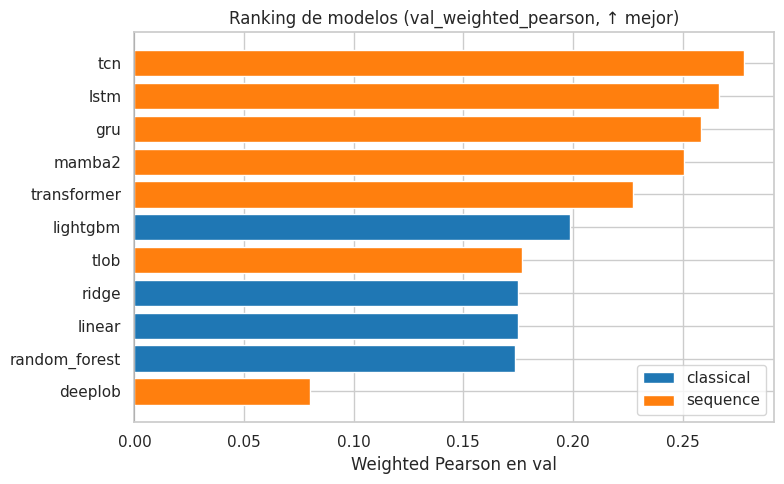

In [66]:
# Barplot ordenado.
fig, ax = plt.subplots(figsize=(8, 5))
palette = {"classical": "tab:blue", "sequence": "tab:orange"}
colors = [palette[k] for k in results_df["kind"]]
ax.barh(results_df["model"][::-1], results_df["val_weighted_pearson"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("Weighted Pearson en val")
ax.set_title("Ranking de modelos (val_weighted_pearson, ↑ mejor)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=palette[k], label=k) for k in palette])
fig.tight_layout()
plt.show()

Mejor modelo: tcn  (val_weighted_pearson = +0.2778)


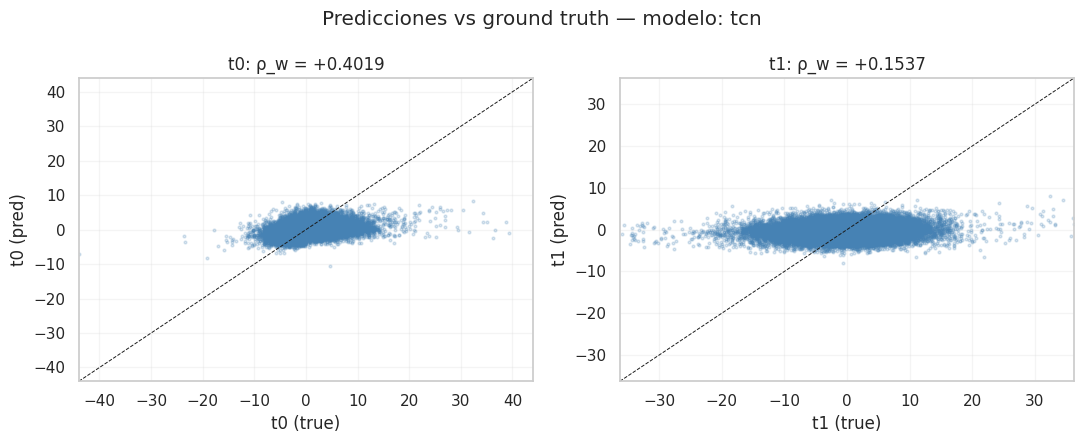

In [67]:
# Diagnóstico del mejor modelo: scatter pred vs true por target.
# Los val_eval (objetos pequeños — solo predicciones + ids) los guardamos en este dict
# para no tener que recomputar; los grandes (modelos, dataframes) ya están liberados o en disco.
all_evals = {}
candidates = [
    ("gru", gru_eval), ("lstm", lstm_eval), ("transformer", tfm_eval),
    ("deeplob", deeplob_eval), ("tcn", tcn_eval), ("mamba2", mamba_eval),
    ("tlob", tlob_eval),
]
if not SKIP_CLASSICAL:
    candidates += [("linear", linear_eval), ("ridge", ridge_eval), ("lightgbm", lgb_eval)]
    if not SKIP_RF and 'rf_eval' in dir() and rf_eval is not None:
        candidates.append(("random_forest", rf_eval))
for k, v in candidates:
    if v is not None:
        all_evals[k] = v

best_row = results_df.iloc[0]
best_name = best_row["model"]
best_kind = best_row["kind"]
best_eval = all_evals[best_name]
print(f"Mejor modelo: {best_name}  (val_weighted_pearson = {best_row['val_weighted_pearson']:+.4f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, j, name in zip(axes, [0, 1], TARGET_COLS):
    ax.scatter(best_eval.targets[:, j], best_eval.predictions[:, j], s=4, alpha=0.2, color="steelblue")
    lim = max(np.abs(best_eval.targets[:, j]).max(), np.abs(best_eval.predictions[:, j]).max(), 1.0)
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.7)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(f"{name} (true)"); ax.set_ylabel(f"{name} (pred)")
    ax.set_title(f"{name}: ρ_w = {best_eval.metrics['per_target'][name]:+.4f}")
    ax.grid(alpha=0.2)
fig.suptitle(f"Predicciones vs ground truth — modelo: {best_name}")
fig.tight_layout()
plt.show()

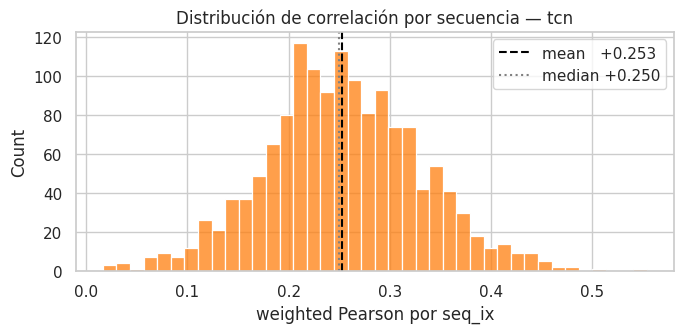

In [68]:
# Distribución de la correlación weighted Pearson por secuencia (mide robustez).
seq_corr = pd.Series(best_eval.per_sequence_corr)
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(seq_corr, bins=40, ax=ax, color="tab:orange")
ax.axvline(seq_corr.mean(),   color="black", linestyle="--", label=f"mean   {seq_corr.mean():+.3f}")
ax.axvline(seq_corr.median(), color="gray",  linestyle=":",  label=f"median {seq_corr.median():+.3f}")
ax.set_xlabel("weighted Pearson por seq_ix")
ax.legend()
ax.set_title(f"Distribución de correlación por secuencia — {best_name}")
fig.tight_layout()
plt.show()

## 9 · Ensemble (promedio ponderado)

Cada target tiene un **techo de señal por modelo** (~0.38 en `t0`, ~0.13 en `t1`):
TCN y Mamba-2, arquitecturas muy distintas, llegan al *mismo* techo por separado —
es un límite de la predictibilidad de los datos, no del modelo. La ganancia fiable
restante viene de **promediar modelos decorrelacionados**: sus errores no están
perfectamente correlacionados, así que la media reduce varianza y suele superar al
mejor individual (sobre todo en `t1`).

Incluimos **LightGBM** además de los modelos de secuencia: es el miembro con el sesgo
inductivo más distinto (árboles vs redes), por lo que sus errores decorrelacionan más
y aporta la mayor ganancia al promedio. Mezclar secuencia + clásico exige alinear las
predicciones por `(seq_ix, step_in_seq)` (los dos evaluadores recorren las filas en
orden distinto), lo cual hacemos explícitamente.

Afinamos pesos convexos sobre las predicciones de **validación** (ya enmascaradas en
`all_evals`) maximizando el weighted-Pearson del scorer, y si el ensemble supera al
mejor individual lo empaquetamos como `solution.zip` final
(`submission.package_ensemble`). El `EnsemblePredictionModel` avanza el estado de
streaming de *cada* miembro en cada paso (el de LightGBM recomputa sus features
ingenieradas incrementalmente) y promedia solo en las filas puntuadas.

In [69]:
from submission.ensemble import tune_ensemble_weights
from submission import package_ensemble

# Candidatos: (nombre, modelo, kind). Los de secuencia comparten el scaler;
# LightGBM es clásico (sesgo inductivo distinto -> más decorrelación -> más ganancia).
_candidates = [
    ("tcn",      tcn_model       if 'tcn_model'     in dir() else None, "sequence"),
    ("mamba2",   mamba_model     if 'mamba_model'   in dir() else None, "sequence"),
    ("gru",      gru_model       if 'gru_model'     in dir() else None, "sequence"),
    ("lstm",     lstm_model      if 'lstm_model'    in dir() else None, "sequence"),
    ("deeplob",  deeplob_model   if 'deeplob_model' in dir() else None, "sequence"),
    ("tlob",     tlob_model      if 'tlob_model'    in dir() else None, "sequence"),
    ("lightgbm", lgb_model       if 'lgb_model'     in dir() else None, "classical"),
]
_members = [(n, m, k) for n, m, k in _candidates if m is not None and n in all_evals]

def _aligned(ev):
    # Ordena las filas puntuadas por (seq_ix, step_in_seq): mezclar miembros de
    # secuencia y clásicos exige alinear (cada evaluador las emite en distinto orden).
    key = ev.seq_ids.astype(np.int64) * 1000 + ev.step_ids.astype(np.int64)
    order = np.argsort(key, kind="stable")
    return key[order], ev.predictions[order], ev.targets[order]

ensemble_zip = None
tune = None
if len(_members) >= 2:
    names = [n for n, _, _ in _members]
    keys0, _, y_ens = _aligned(all_evals[names[0]])
    preds = []
    for n in names:
        k, p, y = _aligned(all_evals[n])
        assert np.array_equal(k, keys0), f"{n}: filas puntuadas no coinciden con {names[0]}"
        assert np.allclose(y, y_ens, atol=1e-4), f"{n}: targets desalineados"
        preds.append(p)

    tune = tune_ensemble_weights(preds, y_ens, step=0.05)
    best_single = max(tune["per_member"])
    for n, s in sorted(zip(names, tune["per_member"]), key=lambda t: -t[1]):
        print(f"  {n:<10} val_wp = {s:+.4f}")
    print(f"\nPesos óptimos: {{{', '.join(f'{n}:{w:.2f}' for n, w in zip(names, tune['weights']))}}}")
    print(f"ENSEMBLE val_wp = {tune['score']:+.4f}  "
          f"(mejor individual = {best_single:+.4f}, ganancia = {tune['score'] - best_single:+.4f})")

    _blend = sum(w * p for w, p in zip(tune["weights"], preds))
    _ens_per = summary(y_ens, _blend)["per_target"]

    if tune["score"] > best_single:
        # Conservamos solo miembros con peso relevante (>=2%), renormalizando.
        kept = [(n, m, k, w) for (n, m, k), w in zip(_members, tune["weights"]) if w >= 0.02]
        wsum = sum(w for *_, w in kept)
        ens_dir = EXPERIMENTS_ROOT / "ensemble" / make_run_id("ensemble")
        ens_dir.mkdir(parents=True, exist_ok=True)
        members = []
        for n, m, k, w in kept:
            if k == "sequence":
                art = ens_dir / f"{n}.pt"; m.save(art)
                members.append(dict(kind="sequence", model_name=n, model_artifact=art,
                                    scaler_state=scaler.state_dict()))
            else:  # classical (LightGBM): recomputa features ingenieradas al vuelo
                art = ens_dir / f"{n}.joblib"; m.save(art)
                members.append(dict(kind="classical", model_name=n, model_artifact=art,
                                    feature_columns=list(m.feature_names_),
                                    with_engineered=True,
                                    rolling_windows=tuple(ROLLING_WINDOWS)))
        utils_py = Path("competition_package/utils.py")
        if utils_py.exists():
            ensemble_zip = package_ensemble(
                run_dir=ens_dir, src_root=Path("src"), utils_py=utils_py,
                members=members, weights=[w / wsum for *_, w in kept])
            print(f"\n>>> El ENSEMBLE es el modelo final. solution.zip: {ensemble_zip}")
            print(f"    miembros: {[(n, round(w / wsum, 2)) for n, _, _, w in kept]}")
    else:
        print("\nEl ensemble no supera al mejor individual; se entrega el modelo único.")

    # Registrar el ensemble en la tabla acumulada de resultados (+ CSV).
    if 'results' in dir():
        results.append({
            "model": "ensemble", "kind": "ensemble",
            "val_weighted_pearson": float(tune["score"]),
            "val_t0": float(_ens_per["t0"]), "val_t1": float(_ens_per["t1"]),
            "members": ", ".join(f"{n}:{w:.2f}" for n, w in zip(names, tune["weights"]) if w >= 0.02),
        })
        if '_flush_results' in dir():
            _flush_results()
        results_df = pd.DataFrame(results).sort_values(
            "val_weighted_pearson", ascending=False).reset_index(drop=True)
        print("\nTabla de resultados actualizada (ensemble incluido):")
        print(results_df[["model", "kind", "val_weighted_pearson", "val_t0", "val_t1"]].to_string(index=False))
else:
    print("Menos de 2 miembros disponibles; se omite el ensemble.")

  tcn        val_wp = +0.2778
  lstm       val_wp = +0.2666
  gru        val_wp = +0.2584
  mamba2     val_wp = +0.2508
  lightgbm   val_wp = +0.1985
  tlob       val_wp = +0.1769
  deeplob    val_wp = +0.0801

Pesos óptimos: {tcn:0.20, mamba2:0.00, gru:0.05, lstm:0.15, deeplob:0.55, tlob:0.00, lightgbm:0.05}
ENSEMBLE val_wp = +0.2889  (mejor individual = +0.2778, ganancia = +0.0111)

>>> El ENSEMBLE es el modelo final. solution.zip: experiments/ensemble/ensemble__20260531-092030/solution.zip
    miembros: [('tcn', 0.2), ('gru', 0.05), ('lstm', 0.15), ('deeplob', 0.55), ('lightgbm', 0.05)]

Tabla de resultados actualizada (ensemble incluido):
        model      kind  val_weighted_pearson   val_t0   val_t1
     ensemble  ensemble              0.288875 0.420697 0.157052
          tcn  sequence              0.277796 0.401861 0.153730
         lstm  sequence              0.266591 0.392691 0.140490
          gru  sequence              0.258436 0.375700 0.141172
       mamba2  sequence      

De esta forma, como hemos presentado al principio del notebook, conseguimos un resultado final en validacion de 0.2889 de correlación poderada de Pearson. Esto deja en claro manifiesto que la unión de varios modelos es más poderos que cualquiera de los modelos individuales.

Sorprendentemente, en modelo que más impacto ha tenido en el ensemble ha sido deeplob, pese a de forma individual no tener un buen resultado. Por tanto, este modelo captura patrones que los demás no son capaces y en capaz de aportar un 55% a la predicción final.